## How well do jobs and skills pay in the US?

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import locale
import ast
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')  # Força locale para inglês

#Getting the data
df = pd.read_csv('data_jobs.csv')

#data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#### Salary Distribution by Job Title

The US is the country with the most data in this dataset, so i'm gonna filter by it.

In [3]:
#Filter for the country
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg']).copy()

In [4]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

# filter the df for the top 6 job titles
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

# order the job titles by median salary
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

#### Visualizing the salary distribution

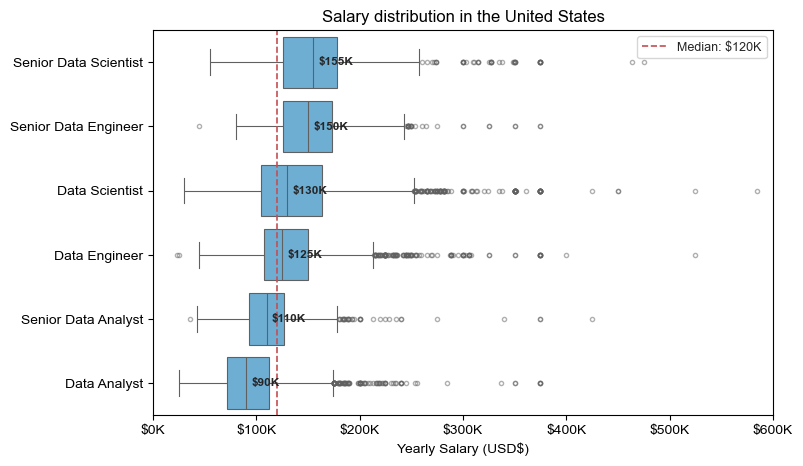

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short',
            order=job_order,
            color="#4CB7F5",        
            saturation=0.6,        
            linewidth=0.8,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))  # outliers discretos
sns.set_theme(style='ticks')


plt.xlim(0,600_000)
ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

mediana_geral = df_US_top6['salary_year_avg'].median()
plt.axvline(mediana_geral, color='r', lw=1.2, linestyle='--', label=f'Median: ${int(mediana_geral/1000)}K')
plt.legend(fontsize=9)

for i, job in enumerate(job_order):
    med = df_US_top6[df_US_top6['job_title_short'] == job]['salary_year_avg'].median()
    plt.text(med + 5000, i, f'${int(med/1000)}K', va='center', fontsize=8.5,fontweight='bold')

plt.title('Salary distribution in the United States')
plt.xlabel('Yearly Salary (USD$)')
plt.ylabel('')
plt.show()

#### Investigating the median Salary vs Skill for Data Analyst

In [6]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

##### Exploding the skills and checking the Correlation

With the results we can see that there is no correlation

In [ ]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('median', ascending=False)

#Checking the correlation between payment and demand
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = df_DA_skills.copy()

df_normalized[['median', 'count']] = scaler.fit_transform(df_normalized[['median', 'count']])


df_normalized['count'].corr(df_normalized['median'])

np.float64(-0.08394337151788925)

##### Getting the top skills

In [ ]:

df_DA_top_pay = df_DA_skills.head(10)
df_DA_top_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values('count', ascending=False)

df_DA_top_skills = df_DA_top_skills.head(10).sort_values('median', ascending=False)

df_DA_top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


#### Visualizing The highest paying and the Most in-demand skills

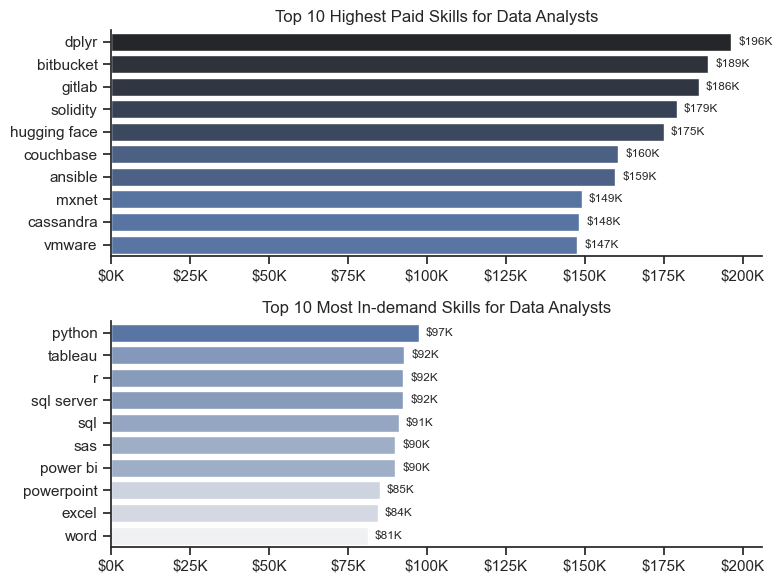

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(8,6))

sns.set_theme(style='ticks')
sns.despine()
sns.barplot(data=df_DA_top_pay,
            x='median',
            y=df_DA_top_pay.index, 
            ax=ax[0], 
            hue='median', 
            palette='dark:b_r' 
            )



ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))



sns.barplot(data=df_DA_top_skills,x='median', y=df_DA_top_skills.index, ax=ax[1],hue='median',palette='light:b')

ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-demand Skills for Data Analysts')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim()) #mantém os dois no mesmo padrão de tamanho
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

#Putting Label in the bars
for container in ax[0].containers:
    ax[0].bar_label(container,
                    fmt=lambda x: f'${int(x/1000)}K',
                    padding=5,
                    fontsize=8.5)

for container in ax[1].containers:
    ax[1].bar_label(container,
                    fmt=lambda x: f'${int(x/1000)}K',
                    padding=5,
                    fontsize=8.5)

fig.tight_layout()
plt.show()